In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent))

from amo.constants import *

from general.plot_settings import colors, paper_settings, colored_line

plt.rcParams.update(paper_settings)
figsize = (4.5, 2.5)

colors = ['k', colors[3], colors[0], colors[1], colors[2], colors[4]]

C:\Users\colin\AppData\Local\Temp\ipykernel_21376\2839085755.py:113: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(x, x, '-', color='gray', linestyle=':')


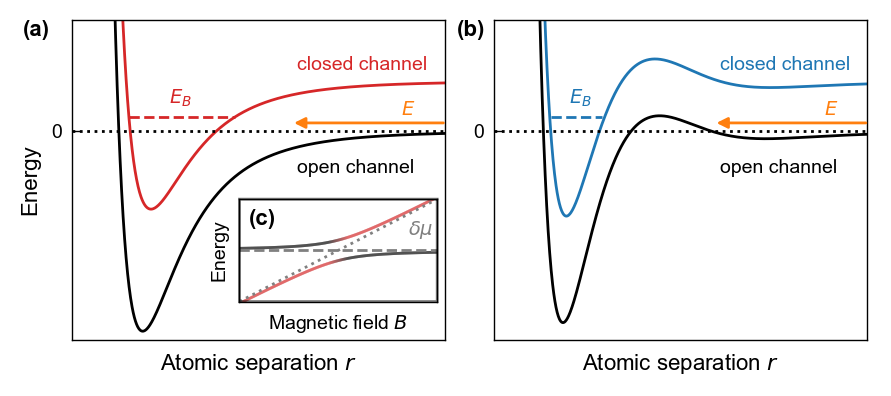

In [35]:
figsize = (4.5, 2)
fig, axs = plt.subplots(1, 2, figsize=figsize)

num = 1000
Rmin = 0.85
Rmax = 3
offset = 0.18

Rs = np.linspace(Rmin, Rmax, num)

def V(R, A=11.5, a6=0.5, a8=1):
    return A*(-a6/R**6 + a8/R**12)

def Vpwave(R, A=16, a6=0.5, a8=1, a2=0.4):
    R0 = 1.5
    return A*(-a6/R**6 + a8/R**12) + a2 * np.exp(-(R-R0)**2/(2*0.35**2))

# ax = axs[1]
ymin = -0.75
ymax = 0.4
xlabel = r'Atomic separation $r$ '
# ylabel = r"Potential $V(R)$"
ylabel = r"Energy"

ax = axs[0]
ax.plot(Rs, V(Rs) , '-', color=colors[0])
ax.plot(Rs, V(Rs, a6=0.4) + offset, '-', color=colors[1])
ax.hlines(0.05, 1.18, 1.79, colors=colors[1], linestyles='--')
ax.text(1.41, 0.1, r"$E_B$", color=colors[1], fontsize=7)
ax.text(2.15, 0.22, "closed channel", color=colors[1], fontsize=7)

ax = axs[1]
ax.plot(Rs, Vpwave(Rs) , '-', color=colors[0])
ax.plot(Rs, Vpwave(Rs, a6=0.45) + offset, '-', color=colors[2])
ax.hlines(0.05, 1.18, 1.47, colors=colors[2], linestyles='--')
ax.text(1.28, 0.1, r"$E_B$", color=colors[2], fontsize=7)
ax.text(2.15, 0.22, "closed channel", color=colors[2], fontsize=7)


# Turn off ticks and labels for both axes
for i, ax in enumerate(axs):
	ax.tick_params(
		axis='both',          # changes apply to the x and y axes
		which='both',         # both major and minor ticks are affected
		bottom=False,         # ticks along the bottom edge are off
		top=False,            # ticks along the top edge are off
		# left=False,           # ticks along the left edge are off
		right=False,          # ticks along the right edge are off
		labelbottom=False,    # labels along the bottom edge are off
		# labelleft=False       # labels along the left edge are off
	)
	ax.set(xlabel=xlabel)
	if i == 0:
		ax.set(ylabel=ylabel)
	ax.set(xlim=(Rmin, Rmax), 
	   ylim=(ymin, ymax)
	   )
	ax.hlines(0.0, Rmin, Rmax, colors=colors[0], linestyles=':')
	ax.text(2.15, -0.15, "open channel", color=colors[0], fontsize=7)
	# ax.text(204.5, -0.5, "attractive", fontsize=8)

	ax.annotate('',
            xy=(2.1, 0.03),          # Arrow tip coordinates
            xytext=(3.025, 0.03),      # Arrow base (tail) coordinates
            arrowprops=dict(arrowstyle='-|>', color=colors[3], lw=1) # Arrow properties
            )
	
	ax.text(2.75, 0.06, r"$E$", color=colors[3], fontsize=7)

	ax.set_yticks([0])


## Avoided crossing inset
from matplotlib.colors import LinearSegmentedColormap

nodes = [
    (0.0, colors[0]), 
    (0.45, colors[0]), 
    (0.55, colors[1]), 
    (1.0, colors[1])
]


custom_cmap = LinearSegmentedColormap.from_list("BlackToRed", nodes, N=256)


def avoided_crossing(x, omega):
    """
    Interpolates between 0 and x.
    omega: Half the energy gap at the crossing point.
    """
    return 0.5 * (x + np.sqrt(x**2 + 4 * omega**2))



ax_inset = axs[0].inset_axes([0.45, 0.12, 0.53, 0.32])
ax = ax_inset

ax.indicate_inset_zoom(ax_inset, edgecolor="black")

num = 1000
xmin = -0.5
xmax = 0.5
x = np.linspace(xmin, xmax, num)

ymin = -0.5
ymax = 0.5
xlabel = r'Magnetic field $B$'
ylabel = r"Energy"

colored_line(x, avoided_crossing(x, 0.1), x, ax, cmap=custom_cmap)
colored_line(x, -avoided_crossing(-x, 0.1), x[::-1], ax, cmap=custom_cmap)
ax.plot(x, x, '-', color='gray', linestyle=':')
ax.hlines(0, xmin, xmax, color='gray', linestyle='--')

ax.tick_params(
    axis='both',          # changes apply to the x and y axes
    which='both',         # both major and minor ticks are affected
    bottom=False,         # ticks along the bottom edge are off
    top=False,            # ticks along the top edge are off
    left=False,           # ticks along the left edge are off
    right=False,          # ticks along the right edge are off
    labelbottom=False,    # labels along the bottom edge are off
    labelleft=False       # labels along the left edge are off
	)

ax.set_xlabel(xlabel, fontsize=7)
ax.set_ylabel(ylabel, fontsize=7)
ax.set(xlim=(xmin, xmax),
       ylim=(ymin, ymax) )

ax.text(0.35, 0.15, r"$\delta\mu$", color='gray', fontsize=7)

ax.text(0.05, 0.75, '(c)', transform=ax.transAxes, fontweight='bold', fontsize=8)


fig.tight_layout()  # Note this is done before the labels on purpose.

subplot_labels = ['(a)', '(b)']
positions = [(-0.13, 0.95), (-0.1, 0.95)]
for ax, label, xy in zip(axs, subplot_labels, positions):
	x, y = xy
	ax.text(x, y, label, transform=ax.transAxes, fontweight='bold', fontsize=8)
	
plt.subplots_adjust(top=0.95)

fig.savefig("outputs/interatomic_potentials.pdf")

plt.show()

In [25]:
rvdw = 65 * a_0
mu = mK / 2
V = hbar**2 / (2*mu*rvdw**2)
V/kB

0.0010259401566347043

In [145]:
xmax

0.5

In [146]:
np.max(x)

np.float64(0.5)

In [ ]:
# ax.text(196.5, 0.6, "repulsive", fontsize=8)
# ax.text(195, 0.06, "threshold", color='gray', fontsize=8)
# ax.text(204.5, -0.5, "attractive", fontsize=8)

# ax.text(201.5, 0.1, "unitarity", rotation=90, fontsize=8)


# ax.set_ylim(ymin, ymax)
# ax.legend(loc="upper left", fontsize=7)

# Inset for scattering length near zero crossing
# Bmin = 208
# Bmax = 210
# B = np.linspace(Bmin, Bmax, num)
                
# ax_inset = ax.inset_axes([0.63, 0.63, 0.32, 0.32])
# ax_inset.set(xlim=(Bmin, Bmax))
# ax_inset.hlines(0, Bmin, Bmax, colors='gray', linestyles='--', alpha=0.5)
# ax_inset.plot(B, a97(B)/a_0/1e3 , '-', color=color)

# ax_inset.set_xticks([208, 209, 210])
# ax_inset.set_xticklabels(["208", "209", "210"])

# ax.indicate_inset_zoom(ax_inset, edgecolor="black")
# ax_inset.text(209, -0.02, "   zero\ncrossing", fontsize=8)

# # Binding energy inset
# Bmin = 200
# Bmax = 202.14
# B = np.linspace(Bmin, Bmax, num)  # G

# ax_inset2 = ax.inset_axes([0.15, 0.12, 0.32, 0.35])

# ymax = 40
# ymin = np.min(Eb_s97(B)/1e3/h)

# ylabel = r"$E_B$ (kHz)"
# ax_inset2.set(ylabel=ylabel, xlim=(Bmin, 202.5), ylim=(ymin, ymax))
# ax_inset2.hlines(0, Bmin, 202.5, colors='gray', linestyles='--', alpha=0.5)
# # ax.set_box_aspect(0.8)

# ax_inset2.plot(B, Eb_s97(B)/1e3/h, '-', label=r"$M_L=\pm 1$", color='k')
# ax_inset2.vlines(B0_97, ymin, ymax, colors=color, linestyles='--')
# ax.legend(fontsize=8, loc="upper left")